# Credit Scoring

**Objectif :** Développer un modèle de scoring de crédit à la consommation interprétable, permettant d'expliquer les décisions de prêt de manière claire et transparente. Cela est devenu nécessaire pour se conformer aux exigences réglementaires et comprendre les motifs d'un refus de crédit.

In [1]:
# On importe les librairies nécessaires
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from ucimlrepo import fetch_ucirepo

# Configuration de l'affichage des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Présentation et récupération des données

Nous allons maintenant récupérer le jeu de données officiel "Statlog German Credit Data" via l'API `ucimlrepo` (identifiant 144). Les attributs sont renommés selon la documentation officielle de l'UCI afin de remplacer les codes techniques (Attribute1, Attribute2, etc.) par leurs libellés métier réels. Ce sera plus simple pour l'analyse et l'interprétation des résultats.

In [2]:
# Téléchargement du jeu de données
dataset = fetch_ucirepo(id=144)
X = dataset.data.features.copy()
y = dataset.data.targets.squeeze()

# Renommage des colonnes
column_mapping = {
    "Attribute1": "checking_status",
    "Attribute2": "duration_months",
    "Attribute3": "credit_history",
    "Attribute4": "purpose",
    "Attribute5": "credit_amount",
    "Attribute6": "savings_status",
    "Attribute7": "employment_duration",
    "Attribute8": "installment_rate",
    "Attribute9": "personal_status_sex",
    "Attribute10": "other_debtors",
    "Attribute11": "residence_since",
    "Attribute12": "property",
    "Attribute13": "age",
    "Attribute14": "other_installment_plans",
    "Attribute15": "housing",
    "Attribute16": "existing_credits",
    "Attribute17": "job",
    "Attribute18": "num_dependents",
    "Attribute19": "own_telephone",
    "Attribute20": "foreign_worker",
}
X.rename(columns=column_mapping, inplace=True)

# Conversion de la variable cible en binaire : 1 pour "défaut", 0 pour "solvable"
y = y.map({1: 0, 2: 1})

print(f"Dimensions du jeu de données : {X.shape[0]} lignes, {X.shape[1]} variables explicatives.")
print("\nDistribution de la variable cible :")
print(y.value_counts(normalize=True).rename({0: "Solvable", 1: "Défaut"}))

Dimensions du jeu de données : 1000 lignes, 20 variables explicatives.

Distribution de la variable cible :
class
Solvable    0.7
Défaut      0.3
Name: proportion, dtype: float64


## Analyse exploratoire des données

Passons à l'analyse exploratoire des données (EDA) pour mieux comprendre la structure du dataset et identifier les relations entre les variables explicatives et la variable cible.

Le dataset présente un déséquilibre de classe naturel : 70 % de profils solvables contre 30 % d'incidents de paiement. Nous allons devoir prendre en compte ce déséquilibre lors de la modélisation pour éviter que le modèle ne soit biaisé vers la classe majoritaire.

Examinons visuellement l'impact de deux facteurs clés : la durée de l'emprunt et le montant emprunté.

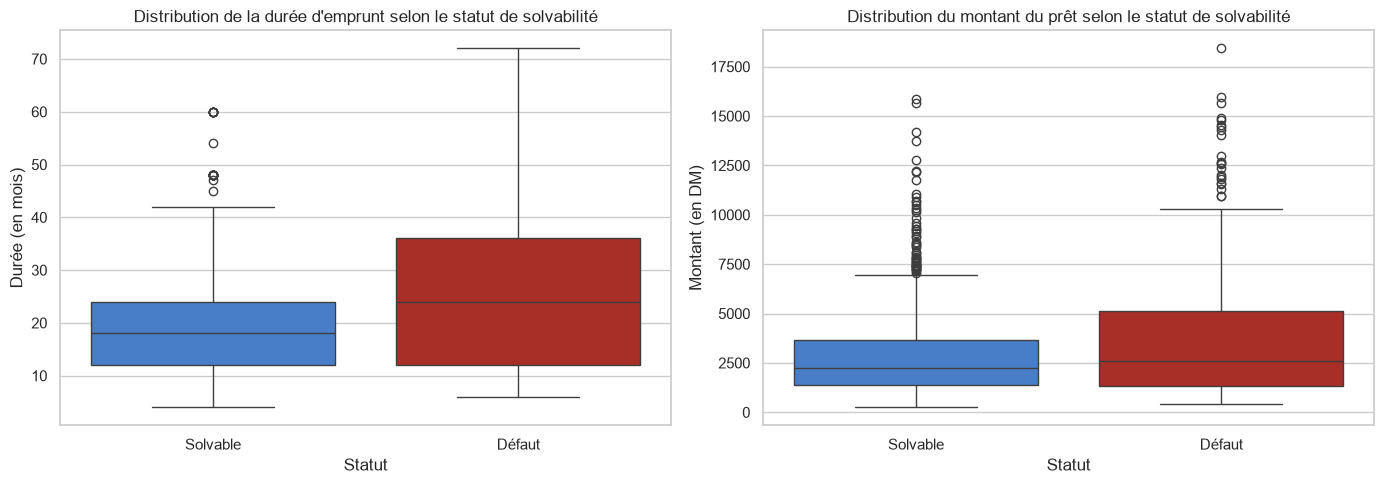

In [3]:
# Création de 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Durée d'emprunt selon le statut de solvabilité
sns.boxplot(
    x=y,
    y=X["duration_months"],
    hue=y,
    palette=["#327bdc", "#bc1c13"],
    legend=False,
    ax=axes[0],
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Solvable", "Défaut"])
axes[0].set_title("Distribution de la durée d'emprunt selon le statut de solvabilité")
axes[0].set_ylabel("Durée (en mois)")
axes[0].set_xlabel("Statut")

# Montant du prêt selon le statut de solvabilité
sns.boxplot(
    x=y,
    y=X["credit_amount"],
    hue=y,
    palette=["#327bdc", "#bc1c13"],
    legend=False,
    ax=axes[1],
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Solvable", "Défaut"])
axes[1].set_title("Distribution du montant du prêt selon le statut de solvabilité")
axes[1].set_ylabel("Montant (en DM)")
axes[1].set_xlabel("Statut")

plt.tight_layout()
plt.show()

On remarque que les profils solvables empruntent sur une plus courte durée et pour des montants plus faibles, tandis que les profils à risque ont tendance à emprunter sur des durées plus longues et pour des montants plus élevés. Cela suggère que ces deux variables sont des indicateurs importants du risque de crédit.

## Préparation des données

Les variables numériques ne sont pas du tout sur les mêmes échelles : l'âge varie entre 19 et 75 ans, tandis que le montant du crédit peut atteindre plusieurs milliers de DM (Deutsche Mark). Si on ne fait rien, l'algorithme risque de donner beaucoup trop d'importance aux variables ayant des grandes échelles.

Nous allons préparer le prétraitement des données, et partitionner le dataset en 2 ensembles (apprentissage et test). Afin d'éviter toute fuite de données, le prétraitement est encapsulé dans un `ColumnTransformer` :
1. Les variables numériques sont standardisées via `StandardScaler` afin de permettre à la pénalisation L1 de fonctionner correctement.
2. Les variables catégorielles sont encodées via `OneHotEncoder` afin de les transformer en variables binaires. On veille d'ailleurs à supprimer la première modalité de chaque variable catégorielle avec l'option "drop='first'".
3. On partitionne ensuite le dataset en 80% pour l'apprentissage et 20% pour le test, tout en maintenant les proportions de défauts grâce à l'option "stratify=y". Cela permet de garantir que les deux ensembles contiennent une proportion similaire de profils solvables et non solvables, ce qui est crucial pour l'évaluation du modèle.

In [4]:
# Tri des colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Création du préprocesseur pour les variables numériques et catégorielles
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
    ]
)

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=22, stratify=y
)

print(f"Taille de l'échantillon d'apprentissage : {X_train.shape[0]} dossiers")
print(f"Taille de l'échantillon de test           : {X_test.shape[0]} dossiers")

Taille de l'échantillon d'apprentissage : 800 dossiers
Taille de l'échantillon de test           : 200 dossiers


## Modélisation par régression logistique

Pour prédire si un client est à risque (classification binaire), j'ai volontairement écarté les modèles complexes de type forêts aléatoires pour me concentrer sur la **Régression Logistique**. Pourquoi ce choix ? Car les résultats doivent être interprétables pour un analyste métier, on ne doit pas avoir une "boîte noire" qui délivre un verdict sans explication. La régression logistique est un modèle simple, mais puissant, qui permet de quantifier l'impact de chaque variable.

Nous allons entraîner une régression logistique avec une pénalisation L1 pure (`l1_ratio=1.0` via le solveur `saga`). On peut choisir différents solveurs mais ils ne supportent pas tous la pénalisation L1. Il y a un paramètre sur lequel nous pouvons jouer, le paramètre C, plus il est petit (par défaut : 1.0), plus la pénalité appliquée aux coefficients est sévère. Nous le fixons à 0,5 pour obtenir un modèle contenant moins de variables explicatives.

Pour finir, les bons payeurs sont plus nombreux que les mauvais payeurs, ce qui peut biaiser le modèle. Pour corriger ce déséquilibre, j'ai utilisé le paramètre `class_weight='balanced'` pour que l'algorithme accorde une attention égale aux deux classes, et ne biaise pas les résultats.

In [5]:
# Prétraitement et entraînement du modèle
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                l1_ratio=1.0,
                C=0.5,
                class_weight="balanced",
                random_state=22,
                max_iter=1000,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


Dans une régression logistique, l'effet d'une variable s'interprète par son **Odds Ratio** :
* Odds Ratio > 1 : Les emprunteurs présentant ce profil ont un risque de défaut accru.
* Odds Ratio < 1 : Les emprunteurs présentant ce profil ont un risque de défaut moins élevé.

Après avoir identifié les facteurs les plus représentatifs du modèle, nous les affichons sous forme de coefficients dans un tableau, puis dans un graphique pour mieux visualiser leur impact.

In [6]:
# On extrait les variables et coefficients pour interprétation
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

# Création d'un DataFrame
xai_df = pd.DataFrame({
    "Variable": feature_names,
    "Beta": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

# On efface les préfixes générés par ColumnTransformer pour une meilleure lisibilité
xai_df["Variable"] = xai_df["Variable"].str.replace("num__", "").str.replace("cat__", "")

# Et on ne garde que les variables dont le coefficient n'est pas nul (sélectionnées par Lasso)
active_features = xai_df[xai_df["Beta"] != 0].sort_values(by="Odds_Ratio", ascending=False)

# A la fin, on affiche les 5 facteurs qui aggravent et ceux qui réduisent le risque de défaut
top_risk = active_features.head(5)
top_protective = active_features.tail(5)

display_df = pd.concat([top_risk, top_protective])
display_df

,Variable,Beta,Odds_Ratio
38,property_A124,0.362114,1.436362
1,credit_amount,0.333609,1.395997
2,installment_rate,0.319498,1.376437
0,duration_months,0.319089,1.375874
36,property_A122,0.297076,1.345918
29,employment_duration_A74,-0.667946,0.512760
13,credit_history_A34,-0.884273,0.413014
35,other_debtors_A103,-0.937615,0.391560
14,purpose_A41,-1.246603,0.287480
9,checking_status_A14,-1.636218,0.194715


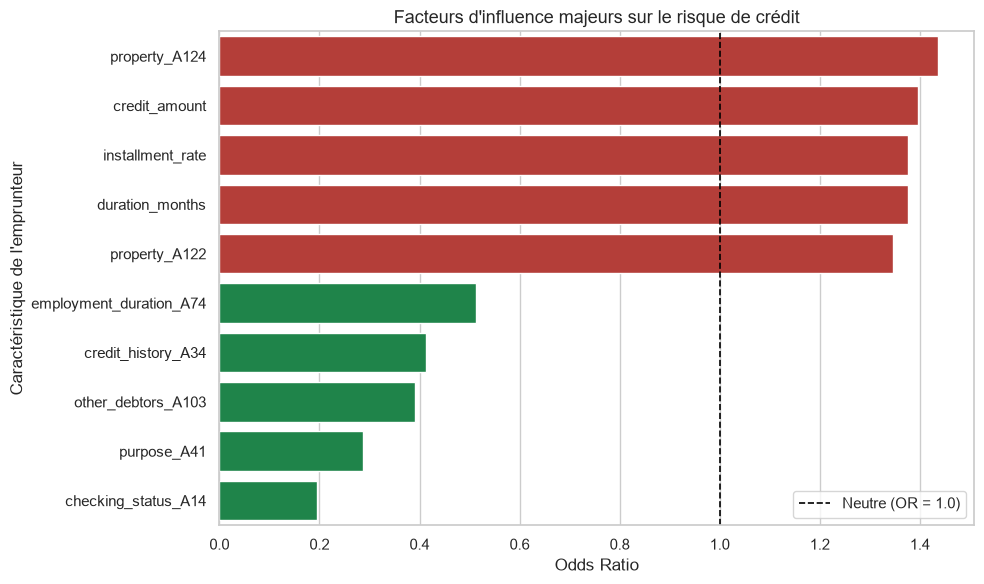

In [7]:
# Passons ce tableau en graphique pour une meilleure visualisation des Odds Ratios
plt.figure(figsize=(10, 6))
colors = ["#c82c24" if or_val > 1 else "#0e9548" for or_val in display_df["Odds_Ratio"]]

sns.barplot(
    x="Odds_Ratio",
    y="Variable",
    data=display_df,
    hue="Variable",
    palette=colors,
    legend=False,
)
plt.axvline(x=1.0, color="black", linestyle="--", linewidth=1.2, label="Neutre (OR = 1.0)")
plt.title("Facteurs d'influence majeurs sur le risque de crédit", fontsize=13)
plt.xlabel("Odds Ratio")
plt.ylabel("Caractéristique de l'emprunteur")
plt.legend()
plt.tight_layout()
plt.show()

Facteurs aggravants :
1. `property_A124` (Aucun bien ou patrimoine inconnu) et `property_A122` (Possède un PEL ou une assurance-vie) : ces deux variables indiquent un manque de patrimoine, ce qui augmente le risque de défaut.
2. `installment_rate` (Taux d'effort) et `credit_amount` (Montant) : plus le montant et la part des mensualités dans le revenu disponible augmentent, plus le risque de défaut augmente.
3. `duration_months` (Durée du crédit) : plus la durée du crédit est longue, plus le risque que le client fasse défaut augmente.

Facteurs réduisant le risque de défaut :
1. `checking_status_A14` (Pas de compte courant) : divise par plus de 4 les chances de défaut. Cela peut sembler paradoxal, mais un profil sans compte courant est souvent multi-bancarisé et possède d'autres actifs financiers, ce qui réduit le risque de défaut.
2. `purpose_A41` (Achat de véhicule d'occasion) : un projet d'achat utilitaire concret avec un risque de défaut réduit de plus de 60 %.
3. `other_debtors_A103` (Possède un garant) : l'emprunteur dispose d'un garant qui s'engage juridiquement à rembourser le prêt en cas de défaut, ce qui réduit son risque d'impayé pour la banque par rapport à un dossier sans aucune garantie.
4. `credit_history_A34` (Comptes critiques / Autres crédits existants) : cela peut sembler étrange, mais un profil ayant déjà négocié des crédits ailleurs est plus fiable qu'un jeune profil n'ayant jamais eu de crédit.
5. `employment_duration_A74` (Employé depuis 4 à 7 ans) : un profil stable possédant un emploi depuis plusieurs années est moins risqué qu'un profil ayant un emploi récent.

## Évaluation des performances

Dans notre contexte, l'erreur la plus critique est le faux négatif, soit l'accord d'un prêt à un emprunteur qui va faire défaut. Nous évaluons donc en priorité le Rappel de la classe "Défaut". Le rappel mesure la capacité du modèle à identifier correctement les clients non solvables parmi tous les clients.

Résultats du modèle sur l'échantillon de test :
              precision    recall  f1-score   support

    Solvable       0.90      0.62      0.73       140
      Défaut       0.49      0.83      0.61        60

    accuracy                           0.69       200
   macro avg       0.69      0.73      0.67       200
weighted avg       0.77      0.69      0.70       200



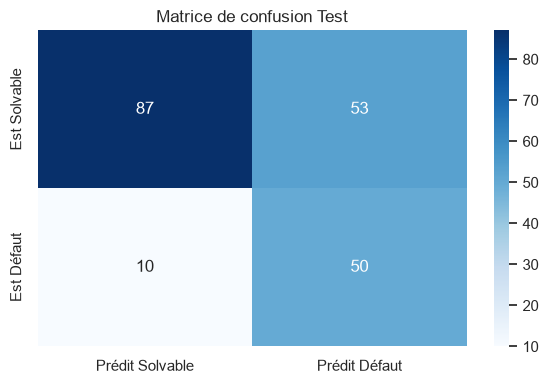

In [8]:
# Evaluation des performances du modèle sur l'échantillon de test
y_pred = model.predict(X_test)

print("Résultats du modèle sur l'échantillon de test :")
print(classification_report(y_test, y_pred, target_names=["Solvable", "Défaut"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Prédit Solvable", "Prédit Défaut"],
    yticklabels=["Est Solvable", "Est Défaut"]
)
plt.title("Matrice de confusion Test")
plt.tight_layout()
plt.show()

L'évaluation sur l'échantillon de test confirme la priorité donnée à la maîtrise du risque d'impayé. Avec un rappel de 83 % sur la classe Défaut, le modèle intercepte 50 des 60 dossiers réellement défaillants.

Cette couverture s'accompagne d'une précision de 49 % sur les défauts, on accepte de perdre des clients solvables pour éviter à tout prix les clients non solvables qui pourraient coûter beaucoup plus cher à la banque. 53 clients solvables sont donc classés parmi les profils à risque. Ce compromis privilégie la protection du bilan financier plutôt que la maximisation du nombre de crédits accordés.

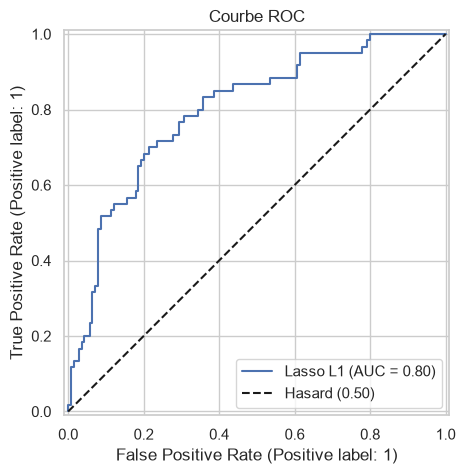

AUC : 0.798
Seuil Youden : 0.65 (Rappel : 70.0%, Faux positifs : 21.4%)


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score, roc_curve

# AUC
y_probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)

# Courbe ROC
RocCurveDisplay.from_predictions(y_test, y_probs, name=f"Lasso L1")
plt.plot([0, 1], [0, 1], "k--", label="Hasard (0.50)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

# 3. Seuil optimal (Youden)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
idx = (tpr - fpr).argmax()

print(f"AUC : {auc:.3f}")
print(f"Seuil Youden : {thresholds[idx]:.2f} (Rappel : {tpr[idx]:.1%}, Faux positifs : {fpr[idx]:.1%})")

La courbe ROC montre que le modèle est performant, avec un AUC de 0,798. Cela signifie qu'un client défaillant tiré au hasard a 79,8 % de chances de recevoir un score de risque plus élevé qu'un client solvable.

Le seuil de Youden (0,65) représente l'optimum géométrique équilibrant au mieux la détection des vrais positifs et la réduction des faux positifs. Cependant, dans un contexte bancaire, il est préférable de descendre le seuil afin d'aller chercher un rappel plus élevé, même si cela augmente un peu les rejets de clients solvables.

## Conclusion et perspectives

Ce projet démontre l'intérêt d'une modélisation par régression logistique pour répondre aux exigences strictes du secteur bancaire, où prédiction et explicabilité doivent être présentes. Grâce à la pénalisation L1 le modèle opère une sélection des variables les plus discriminantes tout en éliminant les moins significatives, permettant ainsi de réduire la complexité du modèle et d'avoir une meilleure interprétabilité.

Le pipeline atteint un score AUC de 0,798 sur l'échantillon de test, il a donc une bonne capacité pour détecter les profils à risque. La matrice de confusion et les métriques associées confirment la priorité donnée à la détection des clients non solvables.

Si l'indice de Youden établit un optimum statistique à un seuil de 0,65 (70 % de rappel), le contexte du crédit justifie l'adoption d'un seuil différent : en captant plus de 83 % des clients défaillants, la banque réduit le risque de pertes financières importantes, même si cela implique d'augmenter le nombre de clients solvables rejetés.

Plusieurs axes permettraient d'enrichir ce projet, notamment le développement d'une interface sous Flask pour restituer en temps réel l'évaluation du score et la décomposition des risques aux analystes crédits.